<a href="https://colab.research.google.com/github/purnachand1186/Breast_Cancer_Analysis_ML/blob/main/2_Evaluation_ML_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OVERVIEW**

This is continutation of what we have found in the '1_Exploratary_Data_Analysis_Breast_Cancer' notebook.

So far we have analyzed the data , removed any unncessary columns, removed outliers and normalized the data, in this notebook, we will be using multiple ML models to process the data and find out the best performing model with accuracy and time it took perform the predictions.

### Load Required Python Libraries

In [1]:
!pip install scikeras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import time



from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder,LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score,make_scorer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#For neaural networks

from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasRegressor


import warnings
warnings.filterwarnings('ignore')

In [3]:
import logging
logging.getLogger().setLevel(logging.CRITICAL)

### Read the data prepared in the first notebook

In [4]:
#read the normalized data from csv file from data folder
cancer_data = pd.read_csv('data/cancer_normalized_df.csv')
cancer_data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,0
1,0.258839,0.202570,0.267984,0.141506,0.678613,0.461996,0.369728,0.402038,0.518687,0.551179,...,0.312633,0.263908,0.136748,0.712739,0.482784,0.427716,0.598282,0.477035,0.454939,0
2,0.533343,0.347311,0.523875,0.380276,0.379164,0.274891,0.264058,0.367793,0.370707,0.157119,...,0.416844,0.511928,0.349194,0.482269,0.223448,0.302236,0.663918,0.295289,0.187853,0
3,0.318472,0.376057,0.320710,0.184263,0.598267,0.445126,0.219447,0.297465,0.573737,0.517060,...,0.429638,0.299766,0.174941,0.622268,0.330753,0.213898,0.534708,0.321506,0.393939,0
4,0.284869,0.409537,0.302052,0.159618,0.674099,0.533157,0.435567,0.464861,0.651515,0.504002,...,0.498667,0.277852,0.136183,0.654626,0.497531,0.430511,0.707904,0.554504,0.342123,0


In [6]:
#split the data for training and testing
X = cancer_data.drop('target', axis=1)
y = cancer_data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Evaluation

Execute Base Models without any param grid and find out the accuracy scores on test data

In [7]:
base_models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Naive Bayes': GaussianNB()
}

In [8]:
results_base= []
for model_name, model in base_models.items():
    pipe = Pipeline([
        # ('scaler', StandardScaler()),
        ('model', model)
    ])
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    results_base.append({'Model': model_name, 'Train Time': train_time, 'Train Accuracy': train_score, 'Test Accuracy': test_score})

In [9]:
results_base_mdls = pd.DataFrame(results_base)
results_base_mdls

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.019599,0.951872,0.968085
1,Decision Tree,0.014062,1.000000,0.925532
2,KNN,0.002634,0.973262,0.978723
3,Random Forest,0.196720,1.000000,0.968085
4,SVM,0.003721,0.975936,0.989362
5,Gradient Boosting,0.463475,1.000000,0.978723
6,Naive Bayes,0.001711,0.935829,0.936170


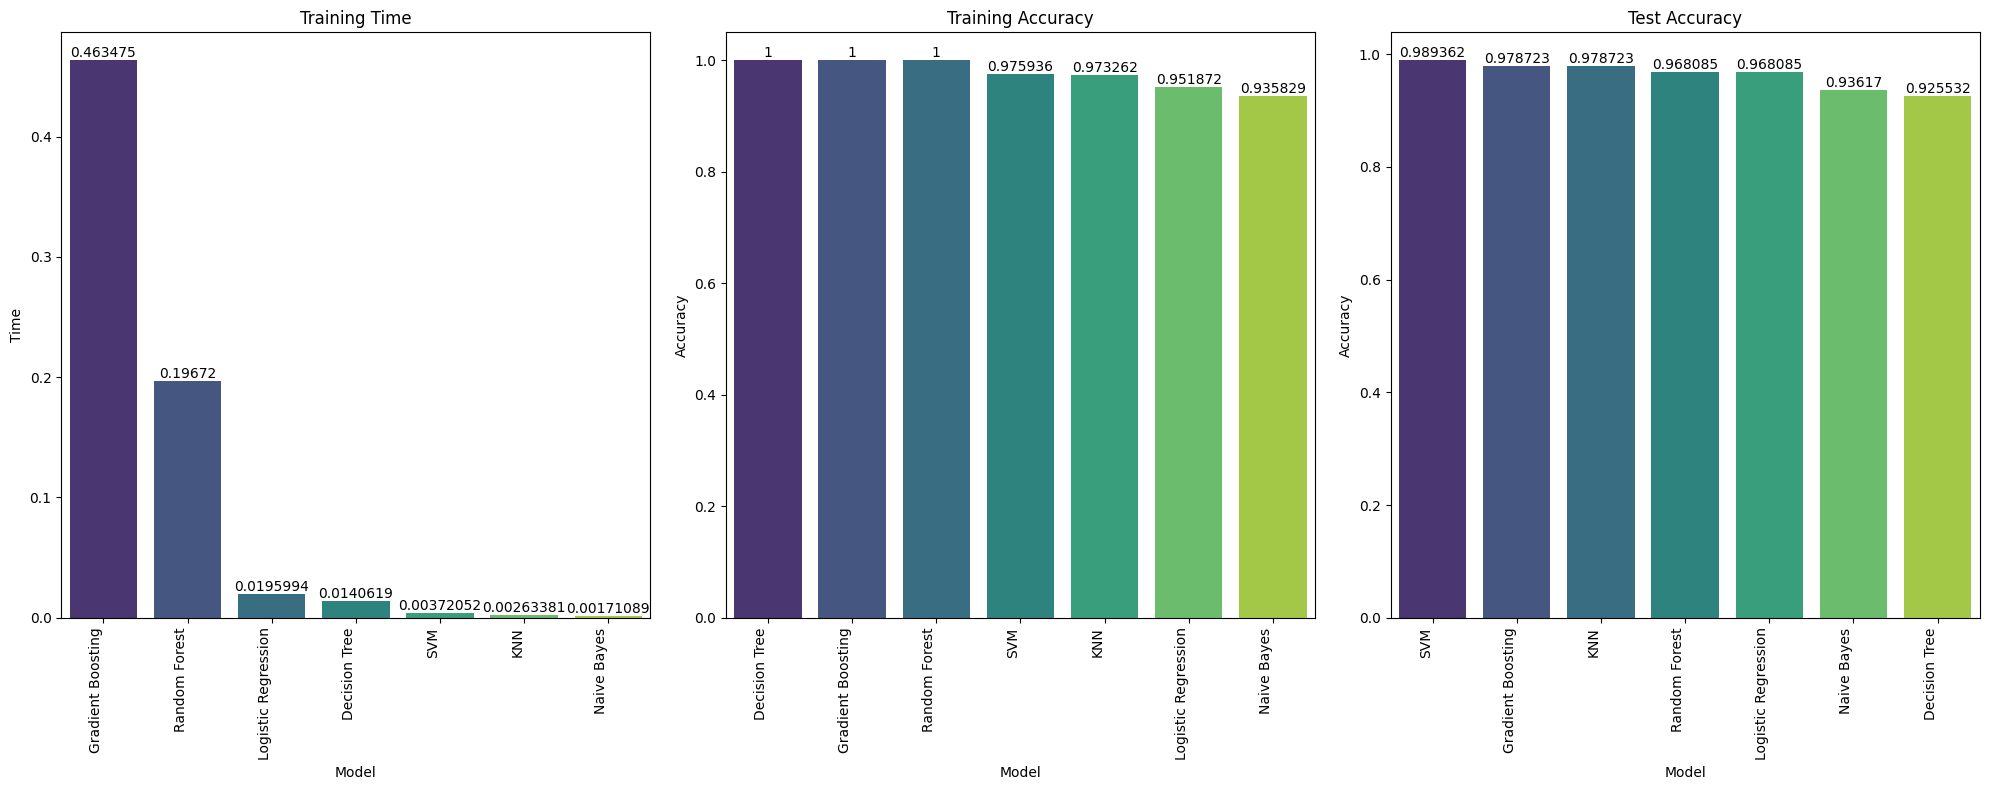

In [10]:
#draw diagrams using the data from above
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
fig = sns.barplot(x='Model', y='Train Time', data=results_base_mdls.sort_values(by='Train Time', ascending=False), palette='viridis', ax=ax[0])
fig.set_title('Training Time')
fig.set_xlabel('Model')
fig.set_ylabel('Time')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Train Accuracy', data=results_base_mdls.sort_values(by='Train Accuracy', ascending=False), palette='viridis', ax=ax[1])
fig.set_title('Training Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Test Accuracy', data=results_base_mdls.sort_values(by='Test Accuracy', ascending=False), palette='viridis', ax=ax[2])
fig.set_title('Test Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)

plt.savefig('images/base_model_comparison.jpeg')
plt.tight_layout()
plt.show()

###Observtions

With just basic default parameters SVM model performed better with Test data and Gradient boosting & KNN follows next.

Overall KNN took less time to train and results an accuracy of 0.978 with test data

##Tuning hyperparameters

In [12]:
# define hyper parameters for the above defined based models
param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10,100]},
    'Decision Tree': {'classifier__max_depth': [3,5,7,9,15]},
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10,20,30]},
    'SVM': {'classifier__C': [0.1, 1, 10,100], 'classifier__kernel': ['linear', 'rbf']},
    'KNN': {'classifier__n_neighbors': [3, 5, 7,9]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1]},
    'Naive Bayes': {}
}

In [ ]:
# Define the scoring metrics for scikit-learn > 1.5.1
# scoring = {
#     'precision': make_scorer(precision_score),
#     'recall': make_scorer(recall_score),
#     'f1': make_scorer(f1_score)
# }

In [13]:
scoring={'precision':'precision',
'recall':'recall',
'f1':'f1'
}

In [14]:
# execute Grid Search
results_advanced = []
for model_name in base_models:
    pipeline = Pipeline([
        ('classifier', base_models[model_name])
    ])
    grid_search = GridSearchCV(pipeline, param_grid=param_grids[model_name], scoring=scoring, refit='f1', cv=5)
    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    best_params = grid_search.best_params_
    best_precision = grid_search.cv_results_['mean_test_precision'][grid_search.best_index_]
    best_recall = grid_search.cv_results_['mean_test_recall'][grid_search.best_index_]
    best_f1 = grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]
    # Get the best estimator
    best_model = grid_search.best_estimator_
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)

    # Append the results
    results_advanced.append({'Model': model_name, 'Train Time': fit_time, 'Train Accuracy': train_score, 'Test Accuracy': test_score, 'Precision': best_precision, 'Recall': best_recall, 'F1': best_f1, 'Best Params':grid_search.best_params_ })

In [15]:
# Set display options to show all rows and columns
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
results_adv = pd.DataFrame(results_advanced)
results_adv


,Model,Train Time,Train Accuracy,Test Accuracy,Precision,Recall,F1,Best Params
0,Logistic Regression,0.101979,0.978610,0.989362,0.968523,0.985714,0.976892,{'classifier__C': 10}
1,Decision Tree,0.116233,0.959893,0.946809,0.932280,0.935649,0.933676,{'classifier__max_depth': 3}
2,KNN,0.108073,0.973262,0.978723,0.965273,0.992857,0.978822,{'classifier__n_neighbors': 5}
3,Random Forest,1.445123,1.000000,0.978723,0.958364,0.982143,0.969941,"{'classifier__max_depth': 10, 'classifier__n_e..."
4,SVM,0.061787,0.989305,0.978723,0.968717,0.992857,0.980497,"{'classifier__C': 10, 'classifier__kernel': 'r..."
5,Gradient Boosting,3.386523,1.000000,0.978723,0.948201,0.982143,0.964756,"{'classifier__learning_rate': 0.1, 'classifier..."
6,Naive Bayes,0.078777,0.935829,0.936170,0.970264,0.935649,0.952316,{}


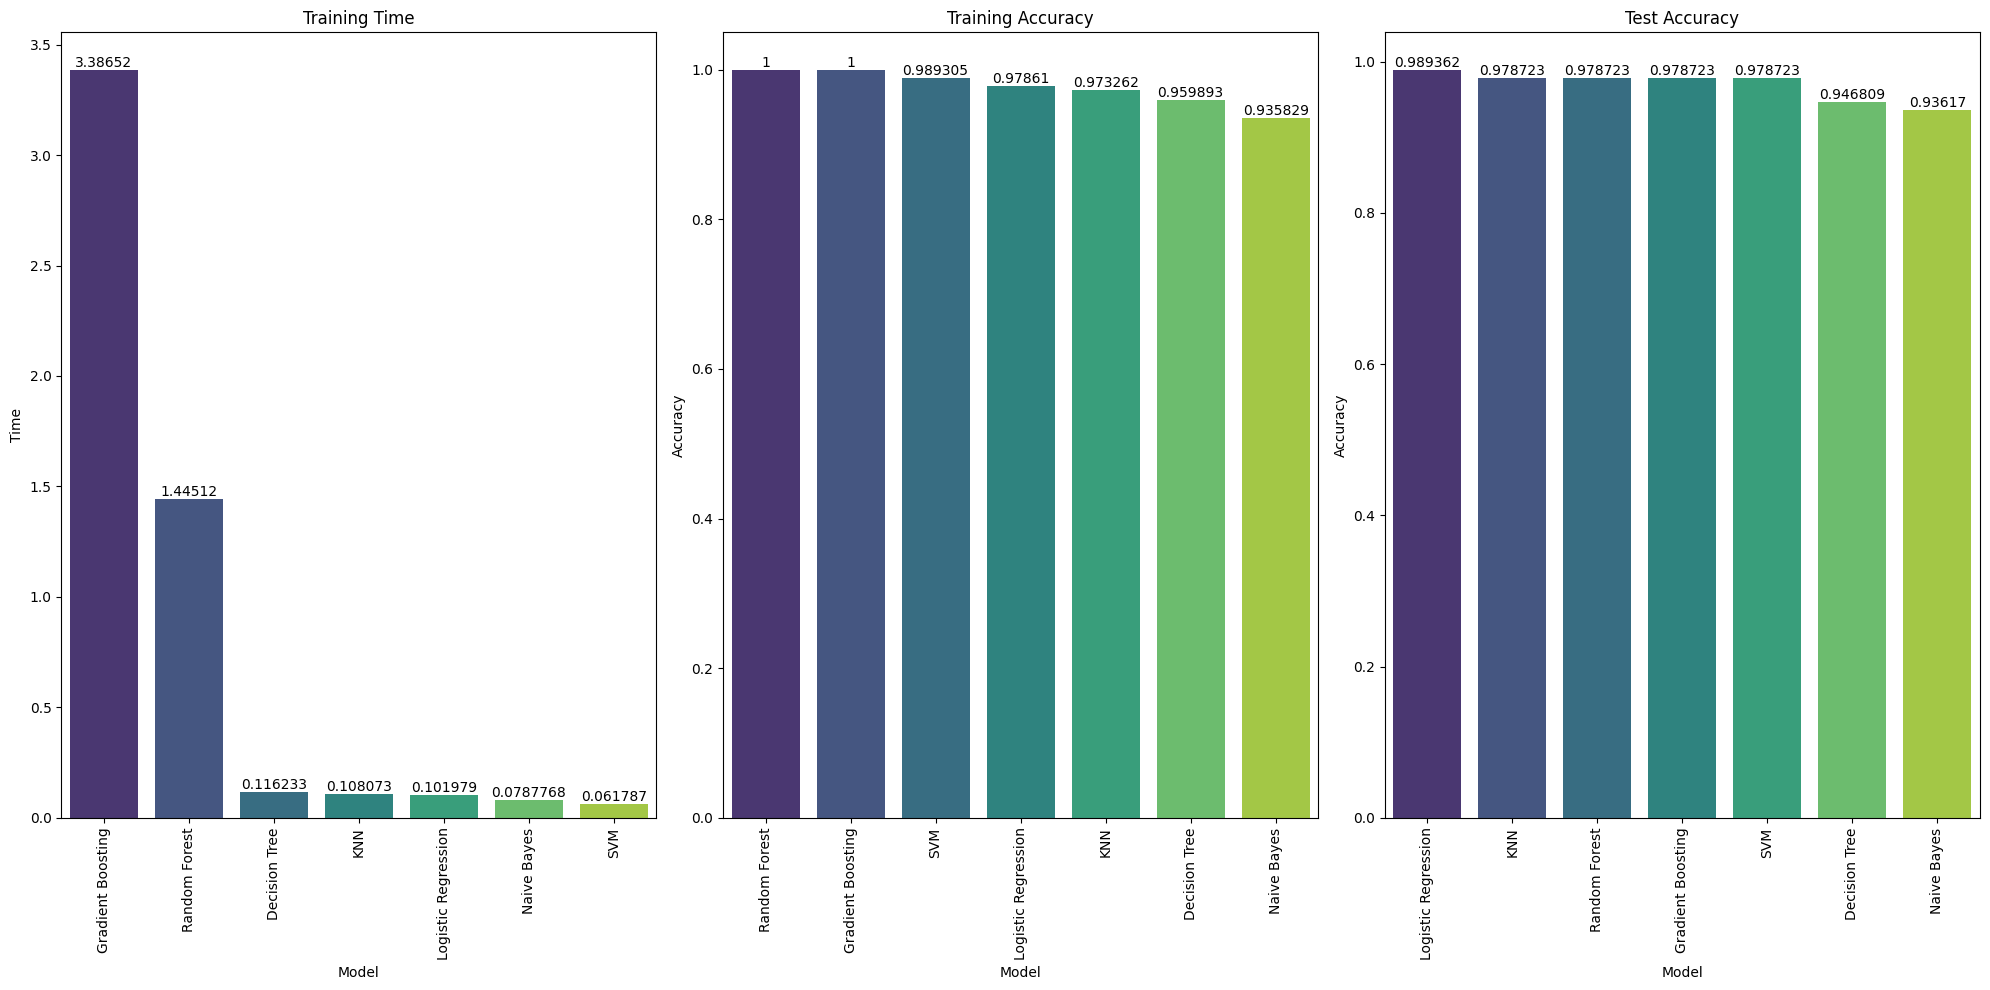

In [17]:
#draw diagrams using the data from above
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
fig = sns.barplot(x='Model', y='Train Time', data=results_adv.sort_values(by='Train Time', ascending=False), palette='viridis', ax=ax[0])
fig.set_title('Training Time')
fig.set_xlabel('Model')
fig.set_ylabel('Time')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Train Accuracy', data=results_adv.sort_values(by='Train Accuracy', ascending=False), palette='viridis', ax=ax[1])
fig.set_title('Training Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Test Accuracy', data=results_adv.sort_values(by='Test Accuracy', ascending=False), palette='viridis', ax=ax[2])
fig.set_title('Test Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)

# for i in range(len(results_adv)):
#     ax[0].text(i - 0.2, results_adv.loc[i, 'Train Time'], f'{results_adv.loc[i, "Train Time"]:.2f}', color='black', ha="center")
#     ax[1].text(i - 0.2, results_adv.loc[i, 'Train Accuracy'], f'{results_adv.loc[i, "Train Accuracy"]:.2f}', color='black', ha="center")
#     ax[2].text(i - 0.2, results_adv.loc[i, 'Test Accuracy'], f'{results_adv.loc[i, "Test Accuracy"]:.2f}', color='black', ha="center")
fig
plt.savefig('images/advanced_model_comparison.jpeg')
plt.tight_layout()
plt.show()

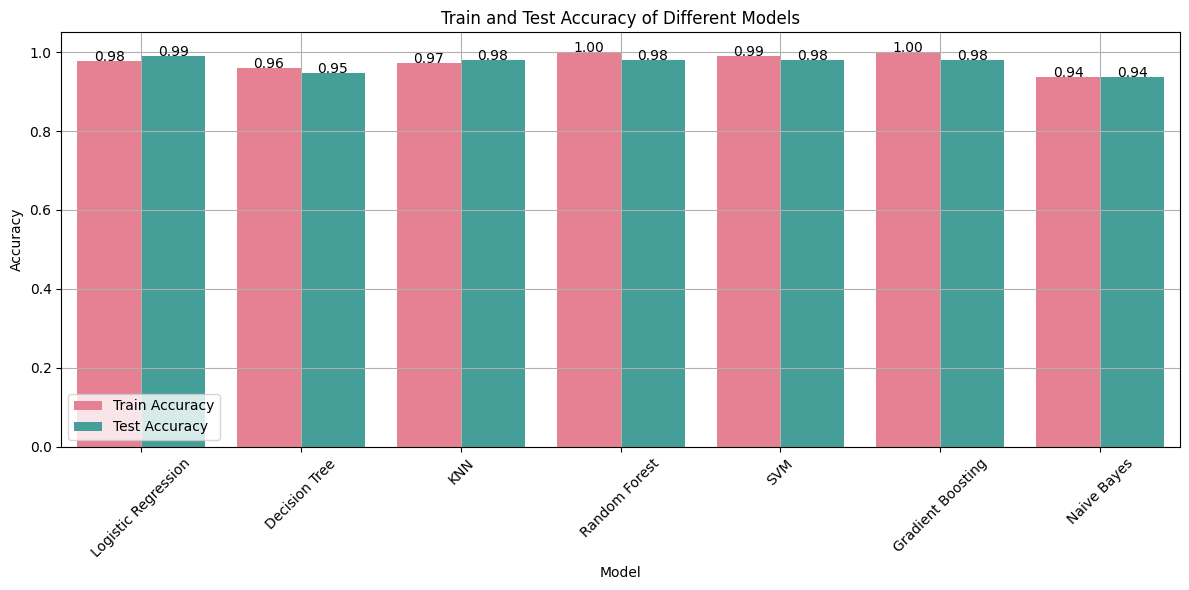

In [18]:
# Melt the DataFrame for easier plotting with sns.barplot
accuracy_df_melted = results_adv.melt(id_vars='Model', value_vars=['Train Accuracy', 'Test Accuracy'], var_name='Dataset', value_name='Accuracy')
# Plot the accuracies using sns.barplot and show values up to two decimals
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Dataset', data=accuracy_df_melted, palette='husl')


for i in range(len(results_adv)):
    plt.text(i - 0.2, results_adv.loc[i, 'Train Accuracy'], f'{results_adv.loc[i, "Train Accuracy"]:.2f}', color='black', ha="center")
    plt.text(i + 0.2, results_adv.loc[i, 'Test Accuracy'], f'{results_adv.loc[i, "Test Accuracy"]:.2f}', color='black', ha="center")

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy of Different Models')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('images/train_test_accuracies_advanced.jpeg')
plt.show()

###Observations

With advanced parameters , surprinsingly Logistic regression performed better with  test data and KNN , Random Forest followed later.

## Use Neaural networks to find out if we find any better scores

In [19]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss = 'bce', metrics = ['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
           epochs = 10, verbose = 0)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Generate classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9500 - loss: 0.2363
Test Accuracy: 94.68%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.95      0.99      0.97        77

    accuracy                           0.95        94
   macro avg       0.94      0.88      0.90        94
weighted avg       0.95      0.95      0.94        94



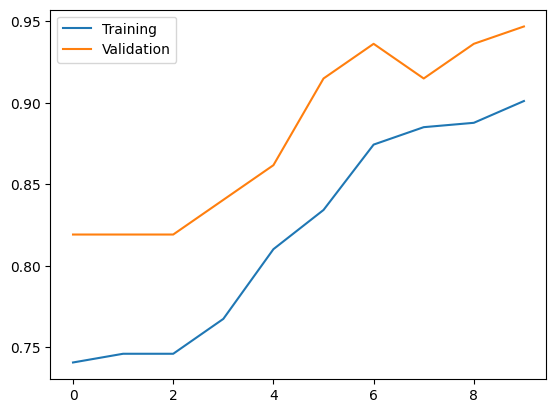

In [20]:
### ANSWER
#print(history.history['acc'][-1])
accuracies = history.history['accuracy']
validation_accuracies = history.history['val_accuracy']


## Plot Training and Validations
plt.plot(accuracies, label = 'Training')
plt.plot(validation_accuracies, label = 'Validation')
plt.legend();

#Using Grid Search in Neaural network to identify best model


In [ ]:
def create_model(**kwargs):
  model = Sequential()
  model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss = 'bce', metrics = ['accuracy'])
  return model

In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.2.2

In [ ]:
# Keras model with SciKeras wrapper
model = KerasRegressor(model = create_model,verbose=2)
tf.random.set_seed(42)
# Hyperparameters to be optimized
param_grid = {
  'model__neurons' : [10, 50, 100],
  'model__activation': ['relu', 'sigmoid'],
  'model__optimizer': ['adam', 'sgd'],
  'batch_size': [1, 10],
  'epochs': [10, 20]
}
# GridSearchCV for hyperparameter tuning
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3)

# Fit the model
grid_result = grid.fit(X, y)

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.